# Spectral Energy Distribution (SED).

In this example, we will generate an SED using our own package. 
Before you run the code below, copy and paste it into a new Python file and save it outside the "sed" folder. 
This GalaxySEDAnalyzer is designed to extract photometry and some physical properties from the SIMBA simulation. However, if you have your own galaxy spectrum, you can modify the code below. You should only change the sed_file_path. 
*** All the outputs will be saved inside the "sed/gsed/outputs".

In [1]:
import numpy as np
import gsed


# 1. Initialize the Analyzer
# This sets up the cosmology and the output folders
spect=gsed.GalaxySEDAnalyzer(filter_dir='sed/gsed/suppliments/filters', 
    output_dir='sed/gsed/outputs')

# 2. Setup your parameters
# Usually, you would load these from a file
try:
    redshifts = np.loadtxt('sed/gsed/suppliments/outputs.txt')
    galId = 1
    snap = 110
    
    # Check if snap exists in your redshift file
    if snap < len(redshifts):
        z = redshifts[int(snap)][1]
    else:
        z = 0.5  # Fallback example redshift
        print("Snap index out of range, using fallback redshift.")

    # 3. Define the path to your specific SED file
    sed_file_path = "sed/gsed/suppliments/sed_flux1_1.txt"

    # 4. Run the Pipeline
    # This extracts fluxes, fits the model, saves .dat files, and saves the .png plot
    print(f"Starting analysis for Galaxy {galId} (Snap {snap})...")
    
    lir, temp = spect.run_analysis(
        galId=galId, 
        snap=snap, 
        z=z, 
        sed_file=sed_file_path
    )

    print("-" * 30)
    print("Analysis Successful!")
    print(f"L_IR (solar): 10^{np.log10(lir):.2f}")
    print(f"Dust Temp: {temp:.2f} K")
    print(f"Files saved in: {spect.output_dir}/")

except Exception as e:
    print(f"An error occurred: {e}")


Starting analysis for Galaxy 1 (Snap 110)...
------------------------------
Analysis Successful!
L_IR (solar): 10^11.57
Dust Temp: 58.50 K
Files saved in: sed/gsed/outputs/






Generated SED looks like..

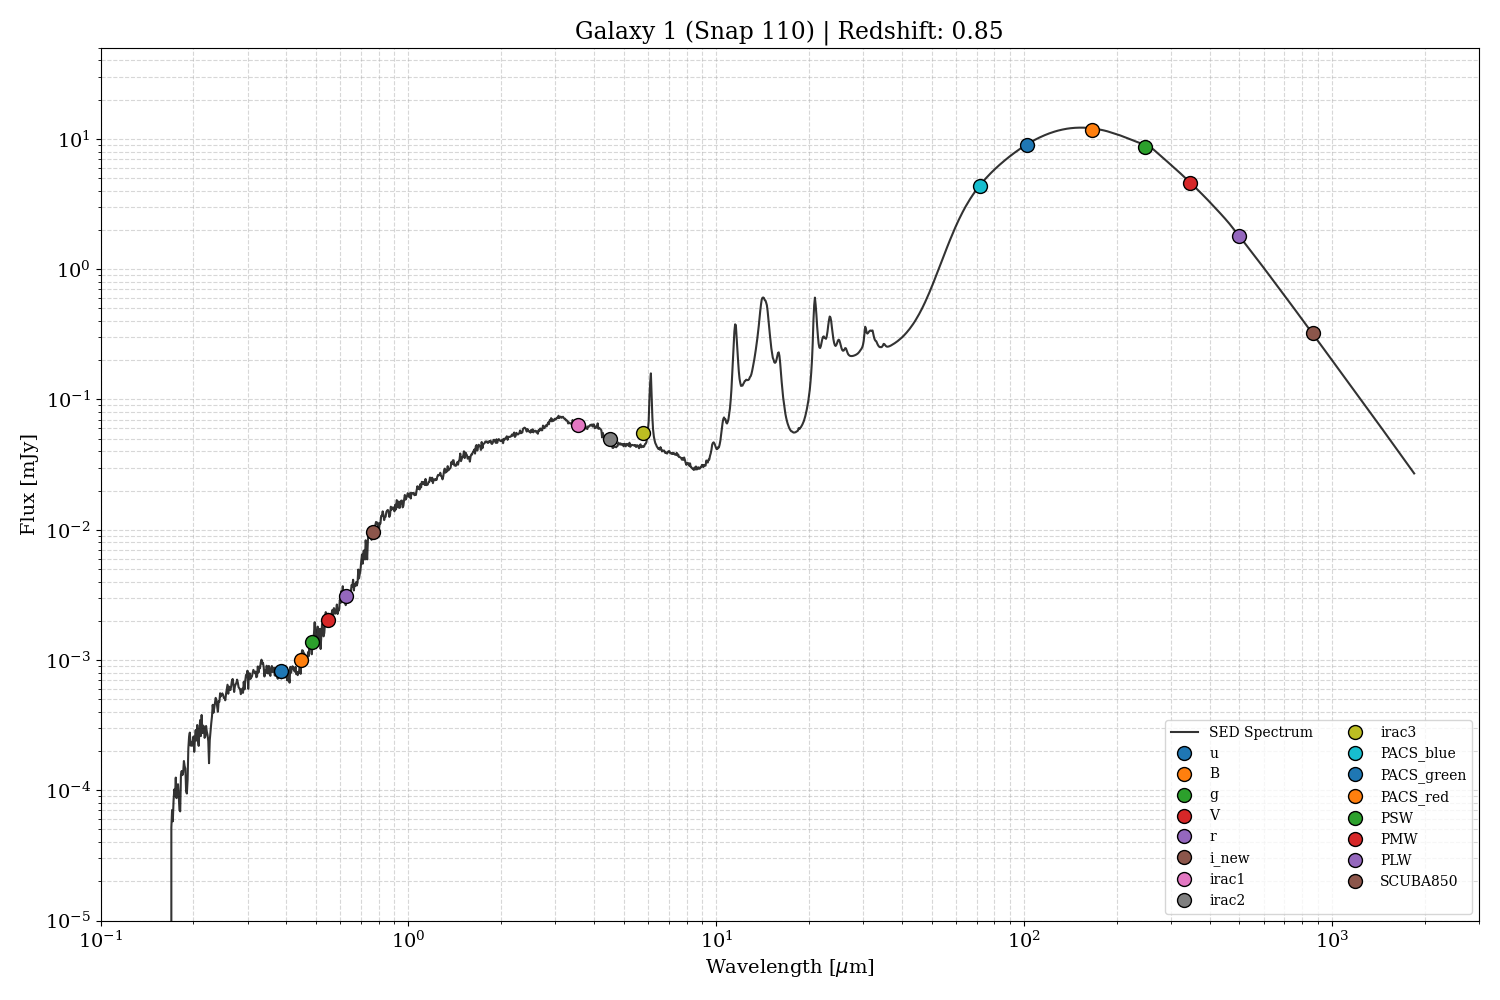